### This is the notebook for analyzing HNSCC data

In [1]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from scipy.sparse import csr_matrix

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

import gseapy as gp
from gseapy import barplot, dotplot
from gseapy import Msigdb

import mygene
mg = mygene.MyGeneInfo()

import sys
sys.path.append("..")

from scripts.utility_functions import t_test, clean_data, read_data

cancer_type = "HNSCC"
#omic_type = "proteomics"
omic_type = "RNAseq"

##### Step 1: organize the data into anndata object

In [2]:

df_transposed = read_data(cancer_type, omic_type)


In [3]:
df_transposed

idx,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.12,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288594.1,ENSG00000288595.1,ENSG00000288596.1,ENSG00000288597.1,ENSG00000288598.1,ENSG00000288600.1,ENSG00000288601.1,ENSG00000288602.1,ENSG00000288603.1,ENSG00000288604.1
C3L-00994_N,10.5417,6.7329,9.8318,10.0917,8.2321,6.2534,13.8516,9.4518,11.7117,9.9218,...,2.2104,3.2357,6.7429,7.5023,6.5031,0.9325,0.0,6.1335,0.0000,0.0
C3L-00995_N,9.9643,8.0048,9.7943,9.7043,8.1647,8.6945,14.0541,10.4142,9.9143,9.6743,...,2.6521,3.2723,6.9655,7.5850,6.3362,1.4590,0.0,6.8256,0.9100,0.0
C3L-00997_N,11.1017,6.0925,9.9117,9.9917,8.1919,8.6918,13.9917,10.6117,11.0017,9.6317,...,0.9711,3.3573,6.7022,7.4320,5.9426,0.0000,0.0,7.0321,1.5414,0.0
C3L-00999_N,11.0617,6.5728,9.7618,10.2317,8.1720,8.5019,13.3016,10.2617,11.2017,9.7818,...,5.4043,3.5315,7.5023,7.7622,7.1824,0.9420,0.0,7.1224,0.9420,0.0
C3L-01237_N,10.7417,7.8422,9.6218,10.0417,8.0821,6.8427,13.6816,9.5618,11.4517,10.0617,...,3.2050,3.5422,7.2824,7.6422,6.8627,0.9372,0.0,7.3624,2.4739,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C3N-04277_T,9.9918,0.0000,10.2917,10.0218,8.9020,8.7520,13.5616,10.8417,10.9717,10.2917,...,2.8193,5.4660,7.1130,7.5526,6.3739,2.1558,0.0,7.6326,2.1558,0.0
C3N-04278_T,11.1917,0.8811,9.5619,9.2719,9.4919,8.4222,12.8716,10.3717,13.9716,10.0618,...,1.4195,3.5216,6.9234,7.3729,6.4043,0.0000,0.0,7.4129,0.8811,0.0
C3N-04279_T,9.2022,1.5692,10.0718,9.6720,9.5021,7.1150,11.3416,10.6817,12.0415,10.2918,...,2.3055,5.0663,7.0451,7.6039,6.4770,0.0000,0.0,7.2646,2.7853,0.0
C3N-04280_T,9.5816,1.6417,10.0917,9.8617,8.0314,6.8710,11.1317,10.1417,9.6417,9.7317,...,1.0466,5.4696,6.8610,7.7313,6.1805,0.0000,0.0,7.3212,2.0694,0.0


In [4]:
### Make the anndata object
obs=pd.DataFrame(
    index=df_transposed.index, 
    data={
        'SampleType': df_transposed.index.str[-1],  # Last character
        'Sample': df_transposed.index.str[:-2]      # All but last two characters
    }
)

var=pd.DataFrame(
    index=df_transposed.columns, 
    data={
        "ensembl_ids_clean" : [x.split(".")[0] for x in df_transposed.columns]
    }
)

adata = ad.AnnData(
    X=df_transposed,
    obs=obs,
    var=var
)

print(adata)

AnnData object with n_obs × n_vars = 154 × 60669
    obs: 'SampleType', 'Sample'
    var: 'ensembl_ids_clean'


In [5]:
### Get gene symbol for ensembl ids (cleaned)
gene_info = mg.querymany(adata.var['ensembl_ids_clean'], scopes="ensembl.gene", fields = "symbol", species="human")
gene_symbols = {item['query']: item.get('symbol', None) for item in gene_info}

# Create a DataFrame to map Ensembl IDs to Gene Symbols
gene_mapping = pd.DataFrame(list(gene_symbols.items()), columns=['ensembl_ids_clean', 'Gene'])

# Merge with adata.var to add Gene_Symbol
adata.var = adata.var.join(gene_mapping.set_index("ensembl_ids_clean"), on='ensembl_ids_clean', how='left')

assert (adata.var.index == df_transposed.columns).all()
assert (adata.obs.index == df_transposed.index).all()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
73 input query terms found dup hits:	[('ENSG00000002586', 2), ('ENSG00000124333', 2), ('ENSG00000124334', 2), ('ENSG00000167393', 2), ('E
1314 input query terms found no hit:	['ENSG00000002079', 'ENSG00000112096', 'ENSG00000130723', 'ENSG00000131484', 'ENSG00000132832', 'ENS


In [6]:
adata.var_names
adata.var
#adata.obs


,ensembl_ids_clean,Gene
idx,,
ENSG00000000003.15,ENSG00000000003,TSPAN6
ENSG00000000005.6,ENSG00000000005,TNMD
ENSG00000000419.12,ENSG00000000419,DPM1
ENSG00000000457.14,ENSG00000000457,SCYL3
ENSG00000000460.17,ENSG00000000460,FIRRM
...,...,...
ENSG00000288600.1,ENSG00000288600,None
ENSG00000288601.1,ENSG00000288601,RNA5SP424
ENSG00000288602.1,ENSG00000288602,C8orf44-SGK3


In [7]:
### Select only protein coding genes
if omic_type == "RNAseq":
    gene_function = pd.read_csv("../../MultiOmics_cancer_landscape_data/proteinatlas.tsv", sep="\t")
    gene_function = gene_function.loc[:, ["Gene", "Ensembl", "Protein class", "Gene description"]]
    
    gene_function = gene_function.drop_duplicates(subset=['Ensembl'], keep='first')
    gene_function

    ori_index = adata.var.index

    # Merge into AnnData
    adata.var = adata.var.merge(
        gene_function,
        left_on = "ensembl_ids_clean",
        right_on="Ensembl",      # merge using the gene name column
        how="left",
        suffixes=('', '_proteinatlas')
    )

    adata.var = adata.var.set_index(ori_index)

    valid_genes_mask = adata.var['Gene_proteinatlas'].notna()

    adata = adata[:, valid_genes_mask].copy()

    print(f"Original number of genes: {len(valid_genes_mask)}")
    print(f"Number of genes remaining after filtering (i.e., successfully annotated): {adata.n_vars}")

Original number of genes: 60669
Number of genes remaining after filtering (i.e., successfully annotated): 20052


In [8]:
adata.var

,ensembl_ids_clean,Gene,Gene_proteinatlas,Ensembl,Protein class,Gene description
idx,,,,,,
ENSG00000000003.15,ENSG00000000003,TSPAN6,TSPAN6,ENSG00000000003,Predicted membrane proteins,Tetraspanin 6
ENSG00000000005.6,ENSG00000000005,TNMD,TNMD,ENSG00000000005,Predicted membrane proteins,Tenomodulin
ENSG00000000419.12,ENSG00000000419,DPM1,DPM1,ENSG00000000419,"Disease related genes, Enzymes, Human disease ...",Dolichyl-phosphate mannosyltransferase subunit...
ENSG00000000457.14,ENSG00000000457,SCYL3,SCYL3,ENSG00000000457,"Enzymes, Predicted intracellular proteins",SCY1 like pseudokinase 3
ENSG00000000460.17,ENSG00000000460,FIRRM,C1orf112,ENSG00000000460,Predicted intracellular proteins,Chromosome 1 open reading frame 112
...,...,...,...,...,...,...
ENSG00000288529.1,ENSG00000288529,LOC128092253,ENSG00000288529,ENSG00000288529,Predicted intracellular proteins,Novel protein
ENSG00000288558.1,ENSG00000288558,DUS4L-BCAP29,DUS4L-BCAP29,ENSG00000288558,Predicted membrane proteins,DUS4L-BCAP29 readthrough
ENSG00000288570.1,ENSG00000288570,LOC128092248,ENSG00000288570,ENSG00000288570,Predicted intracellular proteins,Novel protein


In [9]:
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"

adata.write(object_file, compression="gzip")

##### Step 2: ML

In [7]:
### Main ML workflow 

# Load data
object_file = f"../../MultiOmics_cancer_landscape_data/{cancer_type}/Object/{cancer_type}_{omic_type}.h5ad"
adata = ad.read_h5ad(object_file)

X = adata.X
y_ori = adata.obs["SampleType"].values
#samples = adata.obs["Sample"].values  # sample names or IDs
samples_type = adata.obs["SampleType"].values
samples = adata.obs.index

# Encode labels
# LabelEncoder assigns integers alphabetically by default, so if your labels are "N" and "T" you’ll usually get "Normal" = 0, "Tumor" = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y_ori)

# Ensure "Normal" = 0, "Tumor" = 1
if encoder.transform(["T"])[0] == 0:
    y = 1 - y  # flip labels

# Split train/test and also get the indices of the test set
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, range(len(y)), test_size=0.3, random_state=42, stratify=y, shuffle=True
)

adata_train = adata[samples[idx_train], ]
adata_test = adata[samples[idx_test], ]

# Train Random Forest
rf = RandomForestClassifier(n_estimators=500, random_state=42)
rf.fit(X_train, y_train)

adata_train = t_test(adata_obj = adata_train, sample_type_col= "SampleType", left_type = "T", right_type="N")

adata_train.var["feature_importance"] = rf.feature_importances_


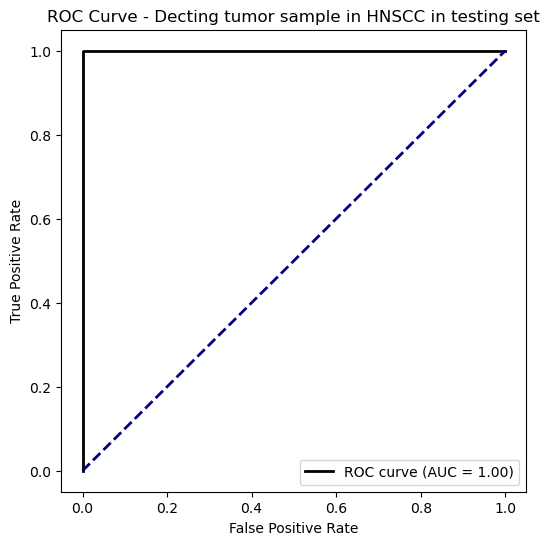

In [8]:

### Prediction
y_proba = rf.predict_proba(X_test)[:, 1]  # Probability of class 1 (Tumor)

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color = "black", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color = "navy", lw=2, linestyle= "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - Decting tumor sample in {cancer_type} in testing set")
plt.legend(loc="lower right")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_ROC_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()


    idx_test       Sample Sample_Type  y_test  y_pred
0        114  C3N-02695_T           T       1   0.954
1         85  C3N-03226_T           T       1   0.974
2         42  C3N-01340_N           N       0   0.022
3        109  C3N-01943_T           T       1   0.898
4         22  C3N-01946_N           N       0   0.092
5         10  C3N-03490_N           N       0   0.030
6        167  C3N-00498_T           T       1   0.976
7        154  C3L-03378_T           T       1   0.968
8         67  C3N-04273_T           T       1   0.894
9         39  C3N-03841_N           N       0   0.030
10       139  C3N-03433_T           T       1   0.986
11        63  C3N-03849_T           T       1   0.968
12        18  C3N-01338_N           N       0   0.002
13       133  C3N-01754_T           T       1   0.978
14       163  C3N-00829_T           T       1   0.980
15       150  C3L-00977_T           T       1   0.990
16        20  C3N-01645_N           N       0   0.048
17       123  C3N-04279_T   

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/88673498.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)


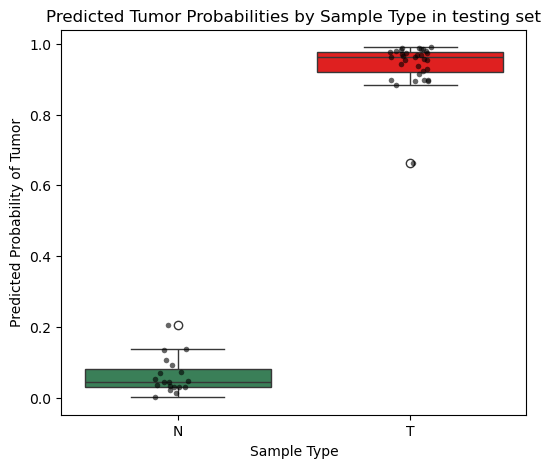

In [9]:

### Create performance DataFrame with Sample info and visualize the proba in testing set
performance = pd.DataFrame({
    "idx_test": idx_test,
    "Sample": samples[idx_test],   # sample names
    "Sample_Type": samples_type[idx_test],
    "y_test": y_test,
    "y_pred": y_proba
})

print(performance)

performance_sort = performance.sort_values("y_pred").reset_index(drop=True)

#pd.set_option("display.max_rows", None)
#print(performance_sort)

### Boxplot on the prediction score in testing set
custom_palette = {"N": "seagreen", "T": "red"}

plt.figure(figsize=(6,5))
sns.boxplot(data=performance, x="Sample_Type", y="y_pred", palette=custom_palette)
sns.stripplot(data=performance, x="Sample_Type", y="y_pred", color="black", size=4, jitter=True, alpha=0.6)
plt.ylabel("Predicted Probability of Tumor")
plt.xlabel("Sample Type")
plt.title("Predicted Tumor Probabilities by Sample Type in testing set")

# Save to PDF
pdf_file = f"../results/figures/{cancer_type}_{omic_type}_Proba_in_testing_set.pdf"
plt.savefig(pdf_file, format="pdf", bbox_inches="tight")

plt.show()

In [10]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
feature_importance_sort.head(5)

,ensembl_ids_clean,Gene,left_mean,right_mean,diff_mean,t_vals,p_vals,feature_importance
idx,,,,,,,,
ENSG00000168497.5,ENSG00000168497,CAVIN2,25.399186596955996,27.57609102246439,-2.176904,-24.734774,1.558945e-44,0.015974
ENSG00000248144.6,ENSG00000248144,ADH1C,22.72131302422239,25.090846832042523,-2.369534,-17.538627,1.051806e-31,0.013382
ENSG00000205221.12,ENSG00000205221,VIT,22.499762908734745,24.785761671976807,-2.285999,-18.396444,3.332748e-32,0.013250
ENSG00000120896.13,ENSG00000120896,SORBS3,24.80570804969883,25.69744313367489,-0.891735,-17.693247,7.512434e-32,0.013015
ENSG00000170275.15,ENSG00000170275,CRTAP,25.39226517499402,24.187136748608584,1.205128,16.149524,2.983702e-29,0.012161


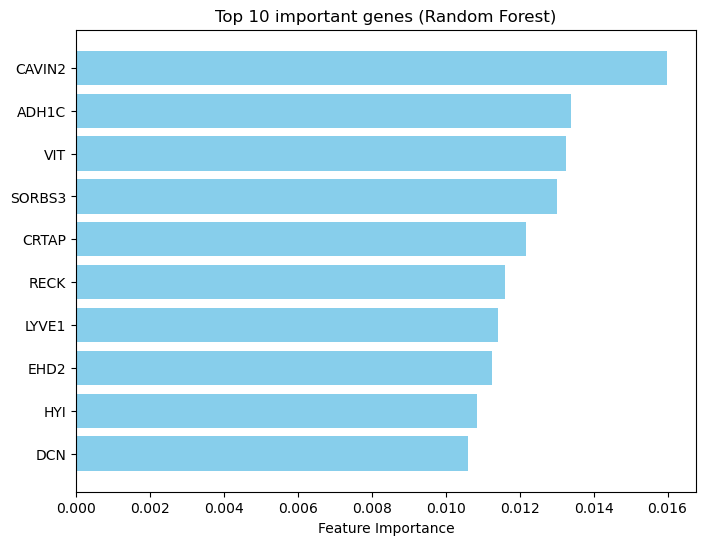

In [11]:
top_n = 10
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance_sort['Gene'][:top_n][::-1],
    feature_importance_sort['feature_importance'][:top_n][::-1],
    color='skyblue'
)
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} important genes (Random Forest)")
plt.show()


#### Step 3: Explore the features with biological input

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


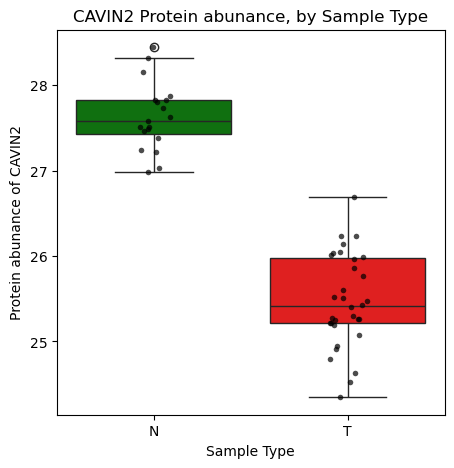

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


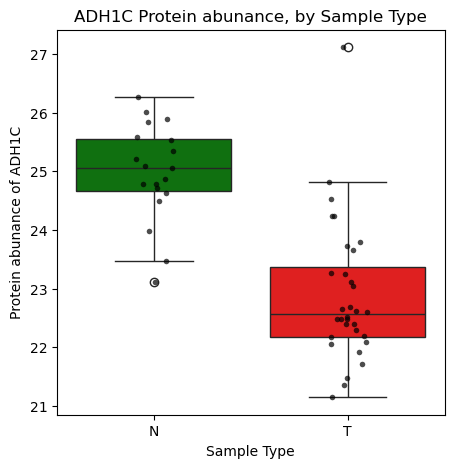

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


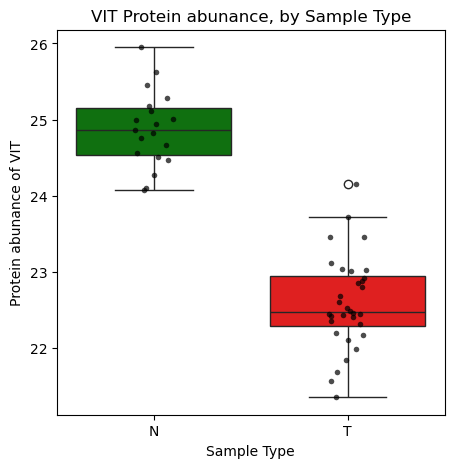

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


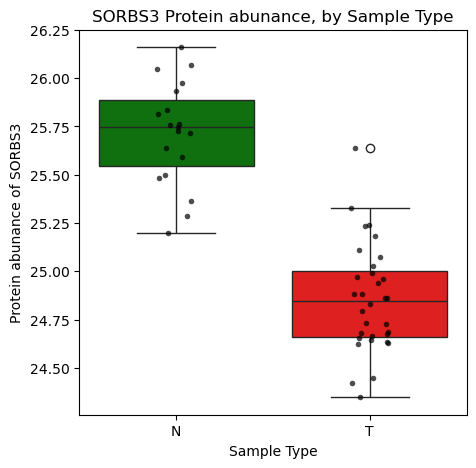

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/1767341051.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


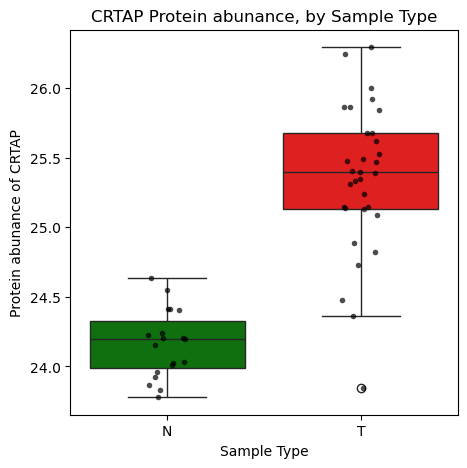

In [12]:
### Boxplot on important genes in testing set
selected_genes = feature_importance_sort.iloc[0:5, ].index.to_list()

df = pd.DataFrame(
    adata_test.X, 
    index=adata_test.obs.index,
    columns=adata_test.var.index  # or adata.var['Gene'] if you prefer gene symbols
).join(adata_test.obs)


for gene in selected_genes:
    
    plt.figure(figsize=(5,5))
    sns.boxplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        palette={"N": "green", "T": "red"}
    )
    sns.stripplot(
        data=df, 
        x="SampleType", 
        y=gene, 
        color="black", 
        size=4, 
        jitter=True, 
        alpha=0.7
    )
    plt.ylabel(f"Protein abunance of {adata.var.loc[gene, 'Gene']}")
    plt.xlabel("Sample Type")
    plt.title(f"{adata.var.loc[gene, 'Gene']} Protein abunance, by Sample Type")
    plt.show()



In [15]:
# check if the NA is imputed
#adata[:, adata.var["Gene"] == "SCN7A" ].X

Total number of samples: 51


/Users/Wendy/miniconda3/envs/multiomics/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/Wendy/miniconda3/envs/multiomics/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


<Figure size 900x900 with 0 Axes>

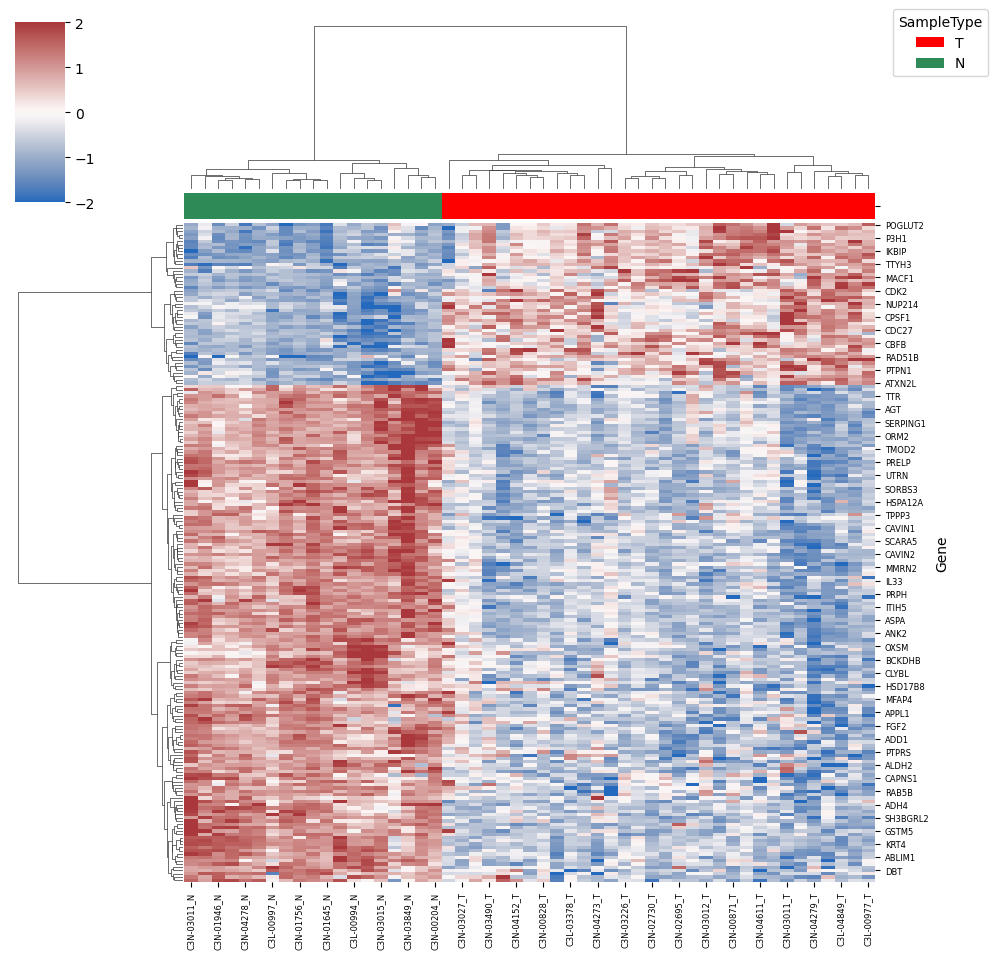

In [13]:

### Heatmap on top 200 important genes on testing set

selected_genes = feature_importance_sort.iloc[0:200, ].index.to_list()
adata_test_selected_genes = adata_test[:, selected_genes]

scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(adata_test_selected_genes.X),
    columns=adata_test_selected_genes.var["Gene"],    # genes
    index=adata_test_selected_genes.obs.index   # samples
)
df_scaled_T = df_scaled.T
# Map disease status to colors
disease_status_col = "SampleType"
lut = {"T": "red", "N": "seagreen"}
dict_colors = adata_test_selected_genes.obs[disease_status_col].map(lut).to_dict()
col_colors = pd.Series(dict_colors)[df_scaled_T.columns]

print(f"Total number of samples: {len(col_colors)}")

# Cluster map
fig = plt.figure(figsize =(9,9))
g= sns.clustermap(
    df_scaled_T,
    col_colors=col_colors,
    cmap="vlag",
    method="ward",
    center=0,
    vmin=-2,
    vmax=2,
    xticklabels=True,
    yticklabels=True
)
# Option 2: Skip some labels (subsample)
yticks = g.ax_heatmap.get_yticks()              # tick positions
ylabels = [lab.get_text() for lab in g.ax_heatmap.get_yticklabels()]  # label texts

skip = 4  # show every 5th gene
g.ax_heatmap.set_yticks(yticks[::skip])
g.ax_heatmap.set_yticklabels(ylabels[::skip], fontsize=6, rotation=0)

# Option 2: Skip some labels (subsample)
xticks = g.ax_heatmap.get_xticks()              # tick positions
xlabels = [lab.get_text() for lab in g.ax_heatmap.get_xticklabels()]  # label texts

skip = 2  # show every 5th gene
g.ax_heatmap.set_xticks(xticks[::skip])
g.ax_heatmap.set_xticklabels(xlabels[::skip], fontsize=6, rotation=90)


# Legend
handles = [Patch(facecolor=lut[name]) for name in lut]
plt.legend(
    handles,
    lut,
    title=disease_status_col,
    bbox_to_anchor=(1, 1),
    bbox_transform=plt.gcf().transFigure,
    loc="upper right"
)
plt.show()


In [14]:
print(np.isfinite(df_scaled_T.values).all()) 

True


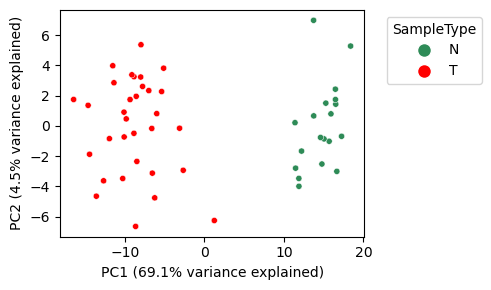

In [15]:

### PCA on top 200 important genes on testing set

scaler = StandardScaler()
df_scaled = scaler.fit_transform(adata_test_selected_genes.X)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

df_pca = pd.DataFrame(
    data = pca_result[:, :2],
    columns= ['PC1', 'PC2'],
    index = adata_test_selected_genes.obs.index
).join(adata_test_selected_genes.obs)

var_explained = pca.explained_variance_ratio_ * 100

disease_status_col = "SampleType"

color_dict = {
    'T': 'red',      # Red
    'N': 'seagreen'   # Green
}
legend_order = ['N', 'T']

fig = plt.figure(figsize =(6,3))
sns.scatterplot(
    data = df_pca,
    x = 'PC1',
    y = 'PC2',
    hue = disease_status_col,
    s = 20,
    palette=color_dict
)

plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance explained)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance explained)')

# Create handles and labels in the specific order
handles = []
labels = []
for category in legend_order:
    if category in color_dict:  # Make sure the category exists in your dictionary
        handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color_dict[category], markersize=10))
        labels.append(category)

# Create the legend with the ordered handles and labels
plt.legend(handles, labels, title=disease_status_col, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout(rect=[0, 0, 0.85, 1])  
plt.show()



/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/2067379197.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()


               Gene_set                               Term Overlap   P-value  \
0  MSigDB_Hallmark_2020  Epithelial Mesenchymal Transition   6/200  0.000009   
1  MSigDB_Hallmark_2020                     Myc Targets V1   4/200  0.001446   
2  MSigDB_Hallmark_2020                     UV Response Up   3/158  0.006831   
3  MSigDB_Hallmark_2020                     Myc Targets V2    2/58  0.008906   
4  MSigDB_Hallmark_2020                    Mitotic Spindle   3/199  0.012779   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000272            0                     0   14.210261   
1          0.021694            0                     0    8.959184   
2          0.055506            0                     0    8.329313   
3          0.055506            0                     0   15.117781   
4          0.055506            0                     0    6.573314   

   Combined Score                                     Genes  
0      164.991315  MMP14;SERPINH1;P3

<Axes: title={'center': 'UpRegulated 49 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

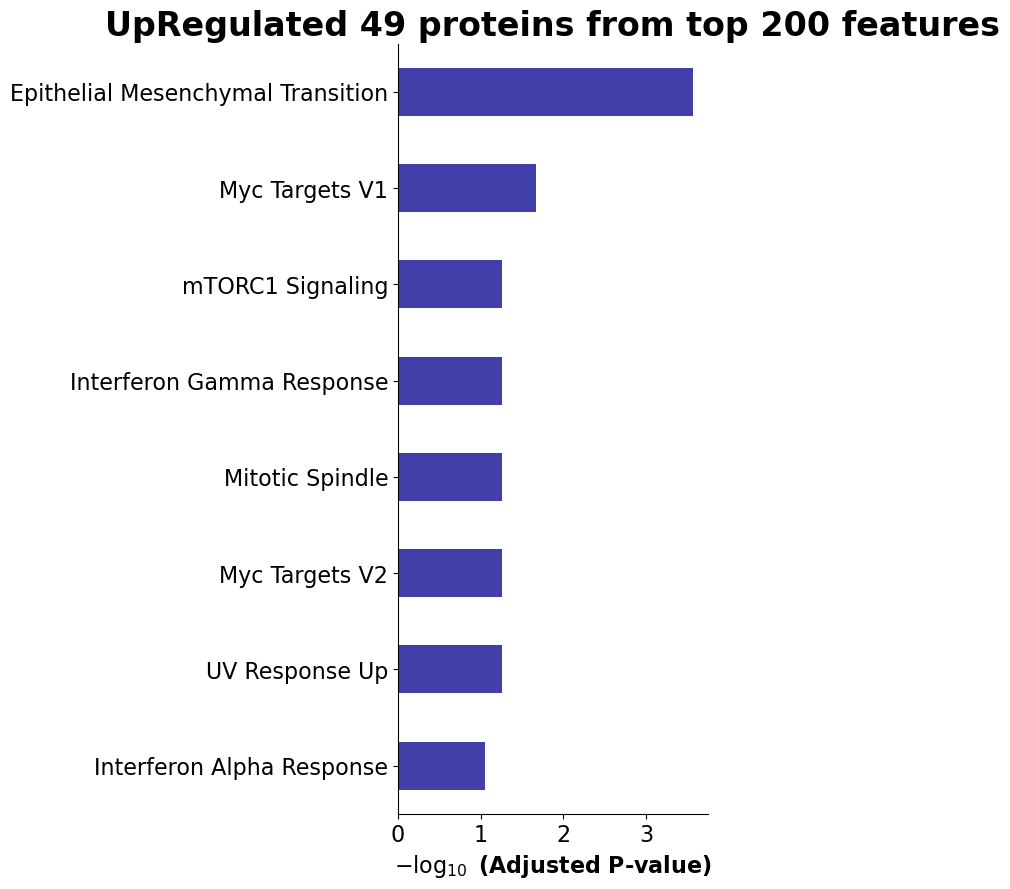

In [16]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] > 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None, # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'UpRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')

/var/folders/bs/xtz8xkb56vl8bb082l_qg1p00000gq/T/ipykernel_24454/4001799050.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()


               Gene_set                   Term Overlap       P-value  \
0  MSigDB_Hallmark_2020           Adipogenesis  12/200  3.996658e-08   
1  MSigDB_Hallmark_2020  Fatty Acid Metabolism   8/158  2.713396e-05   
2  MSigDB_Hallmark_2020             Myogenesis   8/200  1.424519e-04   
3  MSigDB_Hallmark_2020   Bile Acid Metabolism   6/112  2.077310e-04   
4  MSigDB_Hallmark_2020            Coagulation   6/138  6.355845e-04   

   Adjusted P-value  Old P-value  Old Adjusted P-value  Odds Ratio  \
0          0.000001            0                     0    9.028471   
1          0.000461            0                     0    7.346946   
2          0.001614            0                     0    5.727564   
3          0.001766            0                     0    7.707092   
4          0.004322            0                     0    6.180878   

   Combined Score                                              Genes  
0      153.802007  ITIH5;COL15A1;ECHS1;CAVIN1;ALDH2;CAVIN2;EPHX2;...  
1   

<Axes: title={'center': 'DownRegulated 151 proteins from top 200 features'}, xlabel='$- \\log_{10}$ (Adjusted P-value)'>

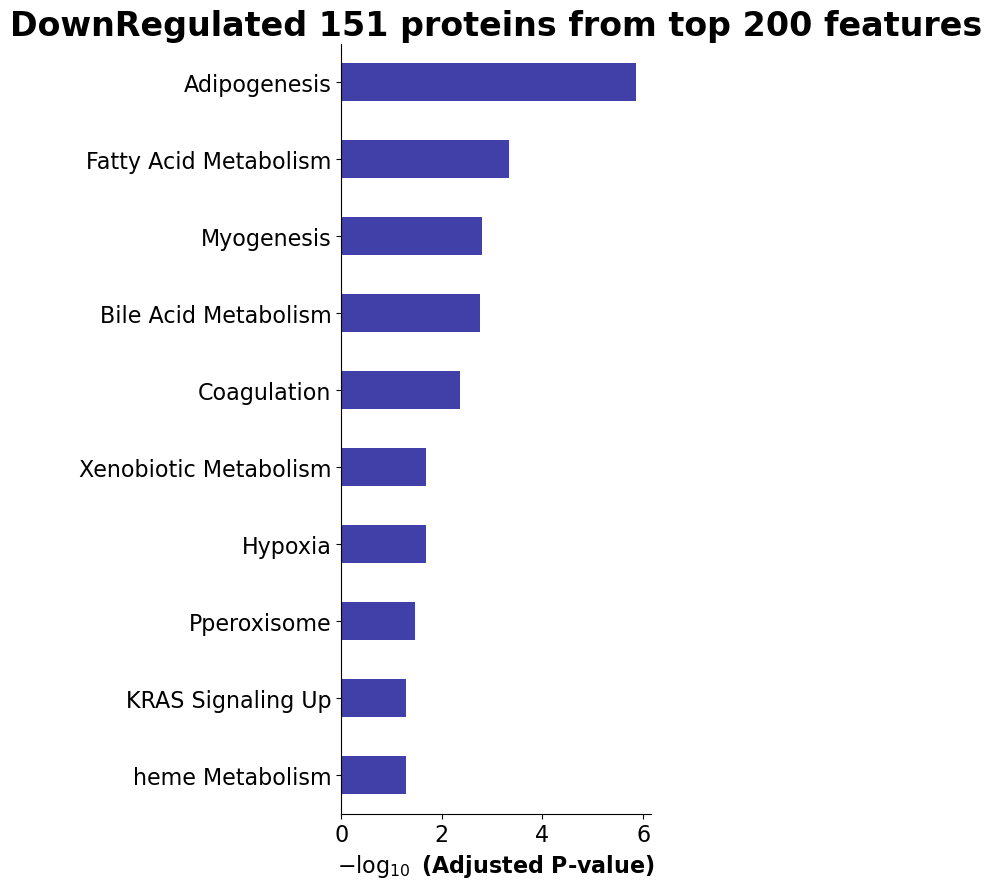

In [17]:
feature_importance_sort = adata_train.var.sort_values(by="feature_importance", ascending=False)
glist = feature_importance_sort.iloc[0:200, ][feature_importance_sort["diff_mean"] < 0]["Gene"].to_list()
# if you are only intrested in dataframe that enrichr returned, please set outdir=None
enr = gp.enrichr(gene_list=glist, # or "./tests/data/gene_list.txt",
                 gene_sets=['MSigDB_Hallmark_2020'],
                 organism='human', # don't forget to set organism to the one you desired! e.g. Yeast
                 outdir=None # don't write to disk
                )
print(enr.results.head(5))
barplot(enr.results, cutoff=0.1, title=f'DownRegulated {len(glist)} proteins from top 200 features', figsize=(4, 10), color='darkblue')